## Libraries and constants

In [1]:
# Source - https://stackoverflow.com/a/9031848
# Posted by astrofrog, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-27, License - CC BY-SA 4.0
import warnings
warnings.filterwarnings('ignore')


TMINUS = '2014-01-01' 
START = '2015-01-01'
END = '2024-12-31'

YEARLY_TRADING_DATES = 252 # n
MONTHLY_TRADING_DATES = YEARLY_TRADING_DATES / 12 # = 21 trading days/month
T_FACTOR = MONTHLY_TRADING_DATES / YEARLY_TRADING_DATES # (1+r/n)^{t_factor*n}

MONEYNESS = {'CC': 1.02, 'PP': 0.98}

## Yahoo Finance scraping and Feature engineering

In [2]:
import yfinance as yf
import pandas as pd
tickers = ['^GSPC', '^TYX']
# Documentation: https://ranaroussi.github.io/yfinance/reference/api/yfinance.download.html#yfinance.download
df = yf.download(tickers, start=TMINUS, end=END, interval='1d',multi_level_index=True)
# Inspiration from https://www.kaggle.com/code/alessandrozanette/s-p500-analysis-using-yfinance-data
df = df.drop(columns=['High', 'Low', 'Open', 'Volume']) # Irrelevant columns
for ticker in tickers:
    if ticker != "^GSPC":
        df.loc[:, ('Close', ticker)] = df.loc[:, ('Close', ticker)] / 100 # From percent to decimal

df5 = pd.read_csv('VIX1Y.csv')
df5['Date'] = pd.to_datetime(df5['Date'], format='%m/%d/%Y')
df5 = df5.set_index('Date')
df = pd.concat([df, df5], axis=1, join='inner')
df = df.drop(columns=['High', 'Low', 'Open', 'Vol.', 'Change %']) # Irrelevant columns
df = df.rename(columns={'Price': ('Close', '^VIX1Y')})

# Source - https://stackoverflow.com/a/43896326
# Posted by MaxU - stand with Ukraine
# Retrieved 2026-04-27, License - CC BY-SA 3.0

newCols = {'Close_^GSPC': 'sp500', 'Close_^TYX': 'rf', 'Close_^VIX1Y': 'VIX1Y'} # rf = risk free rate
df.columns = df.columns.map('_'.join).to_series().map(newCols)
df['VIX1Y'] = df['VIX1Y'] / 100

df

# sp500.tail() # shows the last values
# sp500.describe() # count, max, min, std etc


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/alexanderjarvheden/miniconda3/envs/venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/alexanderjarvheden/miniconda3/envs/venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1043, in launch_instance
    app.start()
  File "/Users/alexanderjarvheden/miniconda3/envs/venv/lib/python3.11/site-packages/ipykernel/kernel

AttributeError: _ARRAY_API not found

[*********************100%***********************]  2 of 2 completed


,sp500,rf,VIX1Y
Date,,,
2014-01-02,1831.979980,0.03919,0.1843
2014-01-03,1831.369995,0.03930,0.1844
2014-01-06,1826.770020,0.03898,0.1829
2014-01-07,1837.880005,0.03881,0.1791
2014-01-08,1837.489990,0.03903,0.1796
...,...,...,...
2024-12-23,5974.069824,0.04784,0.2124
2024-12-24,6040.040039,0.04765,0.2080
2024-12-26,6037.589844,0.04762,0.2074


## Black-Scholes

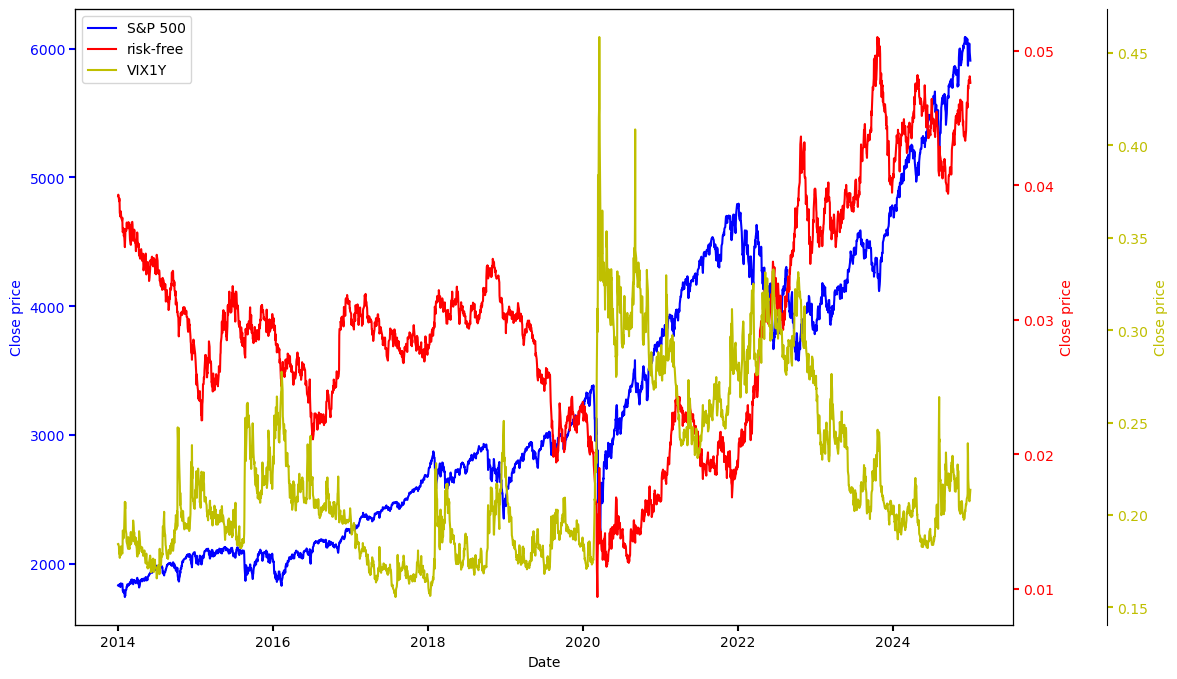

In [3]:
import matplotlib.pyplot as plt

# Source - https://stackoverflow.com/a/14770827
# Posted by Rutger Kassies, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-27, License - CC BY-SA 4.0
fig, ax = plt.subplots(figsize=(15, 8))

# Plot inspiration from: https://matplotlib.org/3.4.3/gallery/ticks_and_spines/multiple_yaxis_with_spines.html
fig.subplots_adjust(right=0.75)

twin1 = ax.twinx()
twin2 = ax.twinx()
twin2.spines.right.set_position(("axes", 1.1))

p1, = ax.plot(df['sp500'], "b-", label="S&P 500")
p2, = twin1.plot(df['rf'], "r-", label="risk-free")
p3, = twin2.plot(df['VIX1Y'], "y-", label="VIX1Y")

ax.set_xlabel("Date")
ax.set_ylabel("Close price")
twin1.set_ylabel("Close price")
twin2.set_ylabel("Close price")

ax.yaxis.label.set_color(p1.get_color())
twin1.yaxis.label.set_color(p2.get_color())
twin2.yaxis.label.set_color(p3.get_color())

tkw = dict(size=4, width=1.5)
ax.tick_params(axis='y', colors=p1.get_color(), **tkw)
twin1.tick_params(axis='y', colors=p2.get_color(), **tkw)
twin2.tick_params(axis='y', colors=p3.get_color(), **tkw)
ax.tick_params(axis='x', **tkw)

ax.legend(handles=[p1, p2, p3])

plt.show()

In [4]:
# Taken from: https://theaiquant.medium.com/mastering-the-black-scholes-model-with-python-a-comprehensive-guide-to-option-pricing-11af712697b7
import numpy as np
import scipy.stats as si
from datetime import datetime

class BlackScholesModel:
    def __init__(self, S, K, T, r, sigma):
        self.S = S        # Underlying asset price
        self.K = K        # Option strike price
        self.T = T        # Time to expiration in years
        self.r = r        # Risk-free interest rate
        self.sigma = sigma  # Volatility of the underlying asset

    def d1(self):
        return (np.log(self.S / self.K) + (self.r + 0.5 * self.sigma ** 2) * self.T) / (self.sigma * np.sqrt(self.T))
    
    def d2(self):
        return self.d1() - self.sigma * np.sqrt(self.T)
    
    def call_option_price(self):
        return (self.S * si.norm.cdf(self.d1(), 0.0, 1.0) - self.K * np.exp(-self.r * self.T) * si.norm.cdf(self.d2(), 0.0, 1.0))
    
    def put_option_price(self):
        return (self.K * np.exp(-self.r * self.T) * si.norm.cdf(-self.d2(), 0.0, 1.0) - self.S * si.norm.cdf(-self.d1(), 0.0, 1.0))


def calculate_historical_volatility(stock_data, window=252):
    log_returns = np.log(stock_data / stock_data.shift(1))
    volatility = np.sqrt(window) * log_returns.std()
    return volatility

# Lambda functions + pandas apply: Source - https://stackoverflow.com/a/60125623
# Posted by Araldo van de Kraats
# Retrieved 2026-04-27, License - CC BY-SA 4.0

df['Call price'] = df.apply(lambda x: BlackScholesModel(S = x.sp500, K = x.sp500*MONEYNESS['CC'], T = 1./4, r = x.rf, sigma = x.VIX1Y).call_option_price(), axis=1)
df['Put price'] = df.apply(lambda x: BlackScholesModel(S = x.sp500, K = x.sp500*MONEYNESS['PP'], T = 1./4, r = x.rf, sigma = x.VIX1Y).put_option_price(), axis=1)

df1 = df.dropna() # remove tminus after first run

# Source - https://stackoverflow.com/a/28681097
# Posted by Adam Smith, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-24, License - CC BY-SA 3.0

import calendar

c = calendar.Calendar(firstweekday=calendar.SUNDAY)
df1 = df
df1['Date'] = df1.index
year = df1['Date'].min().year + 1
month = 1

fridays = df1[df1['Date'] > '3000-04-23']

while(year <= df1['Date'][len(df1['Date'])-1].year):
    monthcal = c.monthdatescalendar(year,month)
    third_friday = [day for week in monthcal for day in week if \
                    day.weekday() == calendar.FRIDAY and \
                    day.month == month][2]
    fridays = pd.concat([fridays, df1[df1['Date'] == str(third_friday)]], ignore_index=True)
    if month == 10:
        month = 1
        year += 1
    else: month += 3

fridays = fridays.set_index('Date')
fridays

,sp500,rf,VIX1Y,Call price,Put price
Date,,,,,
2015-01-16,2019.420044,0.02435,0.2208,76.255865,64.017243
2015-04-17,2081.179932,0.02505,0.2001,70.178130,57.619250
2015-07-17,2126.639893,0.03083,0.1837,66.111680,51.076658
2015-10-16,2033.109985,0.02864,0.2150,75.376720,61.303103
2016-01-15,1880.329956,0.02813,0.2582,85.790576,72.329782
2016-04-15,2080.729980,0.02562,0.2077,73.435355,60.491517
2016-07-15,2161.739990,0.02302,0.2048,74.440172,62.227613
2016-10-21,2141.159912,0.02492,0.2001,72.170598,59.307982
2017-01-20,2271.310059,0.03046,0.1921,74.310485,58.220827


In [5]:
# fridays = fridays.drop([0])
# fridays = fridays.set_index('Date')

def coveredCallProfit(st, k, p, s0):
    # min(St, K) + p − S0
    return (min(st, k) + p - s0) / s0

def protectivePutProfit(st, k, p, s0):
    # St + max(K − St, 0) − p − S0
    return (st + max(k-st,0) - p - s0) / (p + s0)

fridays['CC return'] = fridays.apply(lambda x: coveredCallProfit(
    st=x['sp500'], # price at maturity
    k=fridays.iloc[fridays.index.get_loc(x.name) - 1]['sp500'] * MONEYNESS['CC'] if fridays.index.get_loc(x.name) > 0 else x['sp500'] * MONEYNESS['CC'],
    p=fridays.iloc[fridays.index.get_loc(x.name) - 1]['Call price'], 
    s0=fridays.iloc[fridays.index.get_loc(x.name) - 1]['sp500'] if fridays.index.get_loc(x.name) > 0 else x['sp500']
) if fridays.index.get_loc(x.name) > 0 else 0, axis=1)

fridays['PP return'] = fridays.apply(lambda x: protectivePutProfit(
    st=x['sp500'], # price at maturity
    k=fridays.iloc[fridays.index.get_loc(x.name) - 1]['sp500'] * MONEYNESS['PP'] if fridays.index.get_loc(x.name) > 0 else x['sp500'] * MONEYNESS['PP'],
    p=fridays.iloc[fridays.index.get_loc(x.name) - 1]['Put price'], 
    s0=fridays.iloc[fridays.index.get_loc(x.name) - 1]['sp500'] if fridays.index.get_loc(x.name) > 0 else x['sp500']
) if fridays.index.get_loc(x.name) > 0 else 0, axis=1)

fridays['sp500 return'] = (fridays['sp500'].subtract(fridays['sp500'].shift(1)).div(fridays['sp500'].shift(1))).fillna(0)

fridays['CC cum. return'] = (1+fridays['CC return']).cumprod()
fridays['PP cum. return'] = (1+fridays['PP return']).cumprod()
fridays['sp500 cum. return'] = 1+(fridays['sp500'].subtract(fridays.loc['2015-01-16','sp500'])).div(fridays.loc['2015-01-16','sp500'])

fridays.head(30)
# fridays


,sp500,rf,VIX1Y,Call price,Put price,CC return,PP return,sp500 return,CC cum. return,PP cum. return,sp500 cum. return
Date,,,,,,,,,,,
2015-01-16,2019.420044,0.02435,0.2208,76.255865,64.017243,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
2015-04-17,2081.179932,0.02505,0.2001,70.178130,57.619250,0.057761,-0.001083,0.030583,1.057761,0.998917,1.030583
2015-07-17,2126.639893,0.03083,0.1837,66.111680,51.076658,0.053720,-0.005685,0.021843,1.114585,0.993238,1.053094
2015-10-16,2033.109985,0.02864,0.2150,75.376720,61.303103,-0.012893,-0.042985,-0.043980,1.100215,0.950543,1.006779
2016-01-15,1880.329956,0.02813,0.2582,85.790576,72.329782,-0.038071,-0.048684,-0.075146,1.058328,0.904266,0.931124
2016-04-15,2080.729980,0.02562,0.2077,73.435355,60.491517,0.065625,0.065588,0.106577,1.127781,0.963575,1.030360
2016-07-15,2161.739990,0.02302,0.2048,74.440172,62.227613,0.055293,0.009583,0.038933,1.190139,0.972809,1.070476
2016-10-21,2141.159912,0.02492,0.2001,72.170598,59.307982,0.024915,-0.037234,-0.009520,1.219792,0.936587,1.060285
2017-01-20,2271.310059,0.03046,0.1921,74.310485,58.220827,0.053706,0.032194,0.060785,1.285302,0.966740,1.124734


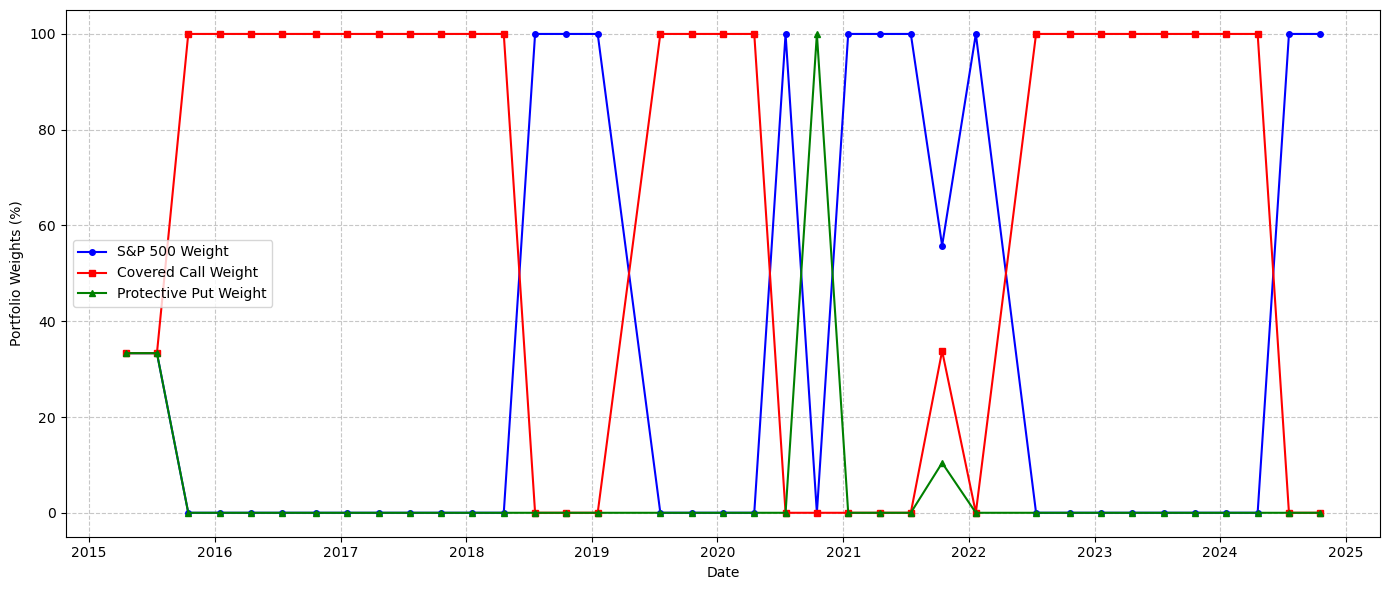

In [6]:
from scipy.optimize import minimize

assets = ['sp500 return', 'CC return', 'PP return']
df_opt = fridays[assets].dropna()

LOOKBACK_WINDOW = 4

returns = [0.0]
cum_return = [1.0]
fridays.at[fridays.index[0], 'Opt. return'] = 0.0
fridays.at[fridays.index[0], 'Cum. Opt. return'] = 1.0

weights = {'date': [], 'sp500':[], 'CC': [], 'PP': []}

for q in range(len(df_opt)-1):
    # Stats for optimization (Last 12 months for stability)
    lookback = df_opt.iloc[max(q-LOOKBACK_WINDOW, 0):q]

    mu = lookback.mean().values
    sigma = lookback.cov().values
    rf_quarterly = fridays['rf'].iloc[q] / 4

    # def statistics(weights):
    #     weights = np.array(weights)
    #     port_return = np.sum(mu * weights)
    #     port_vol = np.sqrt(np.dot(weights.T, np.dot(sigma, weights)))
    #     return port_return, port_vol

    # def min_func_sharpe(weights):
    #     port_return, port_vol = statistics(weights)
    #     return -(port_return - rf_quarterly) / port_vol

    def meanVarianceFunc(weights):
        return np.dot(np.dot(weights.T, sigma), weights)

    # CONSTRAINTS: Sum to 1.0
    target_return = rf_quarterly + 8/100 # add risk premium of 8%
    cons = (
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
        {'type': 'eq', 'fun': lambda x: np.dot(x, mu) - target_return}
    )

    # Bounds: 0 <= w_i <= 1
    bnds = tuple((0.0, 1.0) for _ in range(len(assets)))
    res = minimize(meanVarianceFunc, [1/3]*3, method='SLSQP', bounds=bnds, constraints=cons)

    w_sp500 = res.x[0]
    w_CC = res.x[1]
    w_PP = res.x[2]
    quarterly_return = w_sp500 * fridays['sp500 return'].iloc[q+1] + w_CC * fridays['CC return'].iloc[q+1] + w_PP * fridays['PP return'].iloc[q+1]
    returns.append(quarterly_return)
    cum_return.append(float(cum_return[-1]*(1+quarterly_return)))

    fridays.at[fridays.index[q+1], 'Opt. return'] = quarterly_return
    fridays.at[fridays.index[q+1], 'Cum. Opt. return'] = cum_return[-1]
    weights['date'].append(fridays.index[q+1])
    weights['sp500'].append(w_sp500)
    weights['CC'].append(w_CC)
    weights['PP'].append(w_PP)

weights_df = pd.DataFrame(weights).set_index('date')

# Plotting
plt.figure(figsize=(14, 6))
plt.plot(weights_df.index, 100*weights_df['sp500'], label='S&P 500 Weight', marker='o', markersize=4    , color='b')
plt.plot(weights_df.index, 100*weights_df['CC'], label='Covered Call Weight', marker='s', markersize=4  , color='r')
plt.plot(weights_df.index, 100*weights_df['PP'], label='Protective Put Weight', marker='^', markersize=4, color='g')

# plt.title('Portfolio Weight Rebalancing (Min-Variance Optimization)')
plt.xlabel('Date')
plt.ylabel('Portfolio Weights (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(-5, 105)
plt.tight_layout()
plt.show()


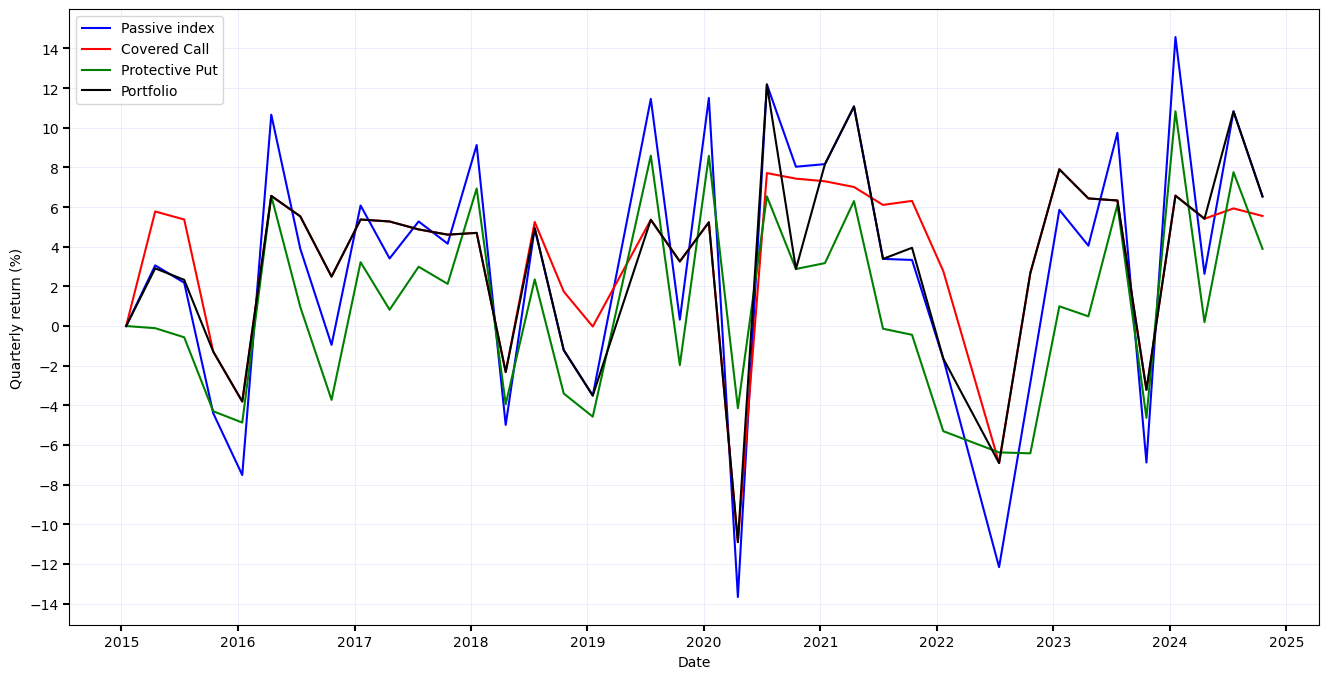

In [7]:
fig, ax = plt.subplots(figsize=(20, 8))

# Plot inspiration from: https://matplotlib.org/3.4.3/gallery/ticks_and_spines/multiple_yaxis_with_spines.html
fig.subplots_adjust(right=0.75)

p1, = ax.plot(fridays.index, 100*fridays['sp500 return'], "b-", label = "Passive index")
p2, = ax.plot(fridays.index, 100*fridays['CC return'],    "r-", label = "Covered Call")
p3, = ax.plot(fridays.index, 100*fridays['PP return'],    "g-", label = "Protective Put")
p4, = ax.plot(fridays.index, 100*fridays['Opt. return'],    "k-", label = "Portfolio")

ax.set_xlabel("Date")
ax.set_ylabel("Quarterly return (%)")

# ax.yaxis.label.set_color(p1.get_color())

tkw = dict(size=4, width=1.5)
ax.tick_params(axis='y', **tkw)
ax.tick_params(axis='x', **tkw)

ax.legend(handles=[p1, p2, p3, p4])
ax.grid(color='lavender', linestyle='-', linewidth=.5)

# Source - https://stackoverflow.com/a/36229671
# Posted by jthomas
# Retrieved 2026-05-03, License - CC BY-SA 3.0
import matplotlib.ticker as ticker
# tick_spacing = 100
# ax.xaxis.set_major_locator(ticker.MultipleLocator(tick_spacing))
tick_spacing = 2
ax.yaxis.set_major_locator(ticker.MultipleLocator(tick_spacing))

plt.show()

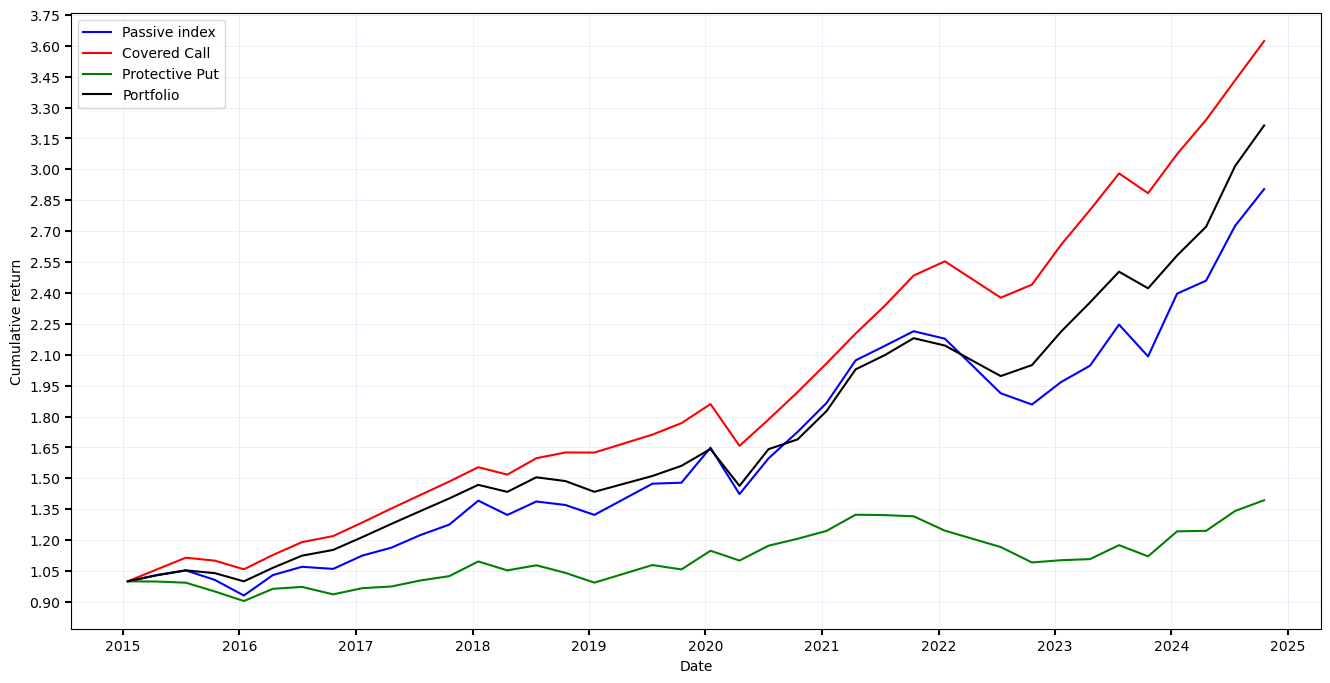

In [9]:
fig, ax = plt.subplots(figsize=(20, 8))

# Plot inspiration from: https://matplotlib.org/3.4.3/gallery/ticks_and_spines/multiple_yaxis_with_spines.html
fig.subplots_adjust(right=0.75)

p1, = ax.plot(fridays.index, fridays['sp500 cum. return'], "b-", label = "Passive index")
p2, = ax.plot(fridays.index, fridays['CC cum. return'],    "r-", label = "Covered Call")
p3, = ax.plot(fridays.index, fridays['PP cum. return'],    "g-", label = "Protective Put")
p4, = ax.plot(fridays.index, fridays['Cum. Opt. return'],    "k-", label = "Portfolio")

ax.set_xlabel("Date")
ax.set_ylabel("Cumulative return")

# ax.yaxis.label.set_color(p1.get_color())

tkw = dict(size=4, width=1.5)
ax.tick_params(axis='y', **tkw)
ax.tick_params(axis='x', **tkw)

ax.legend(handles=[p1, p2, p3, p4])
ax.grid(color='lavender', linestyle='-', linewidth=.5)

# Source - https://stackoverflow.com/a/36229671
# Posted by jthomas
# Retrieved 2026-05-03, License - CC BY-SA 3.0
import matplotlib.ticker as ticker
# tick_spacing = 100
# ax.xaxis.set_major_locator(ticker.MultipleLocator(tick_spacing))
tick_spacing = .15
ax.yaxis.set_major_locator(ticker.MultipleLocator(tick_spacing))

plt.show()